# Lab 2 — Global Post-hoc Explainability
**Teaching assistant** : Eleonora Poeta (eleonora.poeta@polito.it)

---

This lab covers three **global post-hoc** explainability techniques applied to black-box classifiers on the Titanic dataset:

| Technique | What it explains |
|---|---|
| **Permutation Feature Importance** | How much each feature contributes to model performance |
| **Partial Dependence Plot (PDP)** | Marginal effect of one (or two) features on the predicted outcome |
| **Global Surrogate Models** | A white-box model that approximates a black-box model's predictions |

**Guide:**
- ⚙️ Data preprocessing (Titanic)
- 🔀 Permutation Feature Importance
- 📉 Partial Dependence Plots
- 🪞 Global Surrogate Models


## ⚙️ Data Preprocessing (~10 min)

We are using the **Titanic** dataset loaded directly from OpenML.
This section walks you through the full preprocessing pipeline: loading, splitting, imputing, encoding, and scaling.

> 💡 Apply the same good habits from Lab 0: always fit transformations on the **training set only**, then apply them to the test set!


### ⚙️ Step 1 — Imports & Load

In [1]:
# If your dataset is stored on Google Drive, mount the drive before reading it
#from google.colab import drive
#drive.mount('/content/drive')

In [2]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression as LR_sklearn
from sklearn.svm import SVC
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries loaded")

✅ Libraries loaded


### ⚙️ Step 2 — Load the Titanic Dataset

The [Titanic dataset](https://www.kaggle.com/c/titanic) contains passenger information and whether they survived.
We want to predict the column **`survived`** (0 = no, 1 = yes).


In [3]:
# Load dataset from OpenML
df, y = fetch_openml('titanic', version=1, as_frame=True, parser='auto', return_X_y=True)
df["survived"] = y.astype(int)  # Ensure target is integer

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1309, 14)


,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,boat,body,home.dest,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,2,NaN,"St Louis, MO",1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,11,NaN,"Montreal, PQ / Chesterville, ON",1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,NaN,135.0,"Montreal, PQ / Chesterville, ON",0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,NaN,NaN,"Montreal, PQ / Chesterville, ON",0


In [4]:
# Quick overview
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 14 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   pclass     1309 non-null   int64   
 1   name       1309 non-null   str     
 2   sex        1309 non-null   category
 3   age        1046 non-null   float64 
 4   sibsp      1309 non-null   int64   
 5   parch      1309 non-null   int64   
 6   ticket     1309 non-null   str     
 7   fare       1308 non-null   float64 
 8   cabin      295 non-null    str     
 9   embarked   1307 non-null   category
 10  boat       486 non-null    str     
 11  body       121 non-null    float64 
 12  home.dest  745 non-null    str     
 13  survived   1309 non-null   int64   
dtypes: category(2), float64(3), int64(4), str(5)
memory usage: 125.4 KB


In [5]:
# Class balance — important for choosing metrics!
print("Class distribution:")
print(df["survived"].value_counts())
print(f"\nImbalance ratio: {df['survived'].value_counts()[0]/df['survived'].value_counts()[1]:.2f}:1")

Class distribution:
survived
0    809
1    500
Name: count, dtype: int64

Imbalance ratio: 1.62:1


### ⚙️ Step 3 — Stratified Train / Test Split

> 🔑 **Key reminder:** split *before* any transformation. Fitting scalers or imputers on the full dataset causes **data leakage**.


In [6]:
#### START CODE HERE ####
# Split 80% train / 20% test, shuffle=True, random_state=42, stratify by 'survived'
df_train, df_test = train_test_split(df, test_size=0.2, shuffle=True, random_state=42, stratify=df['survived'])
#### END CODE HERE ####

print(f"Train: {len(df_train)} samples | Test: {len(df_test)} samples")
print("\nTrain class distribution:")
print(df_train["survived"].value_counts())

Train: 1047 samples | Test: 262 samples

Train class distribution:
survived
0    647
1    400
Name: count, dtype: int64


### ⚙️ Step 4 — Handle Missing Values

> 🔑 **Key reminder:** compute statistics (mean, median…) on the **training set only**, then apply to both sets.


In [7]:
# Count NaN per column
nan_train = df_train.isna().sum()
nan_test  = df_test.isna().sum()

print("Missing values — Train:")
print(nan_train[nan_train > 0])
print("\nMissing values — Test:")
print(nan_test[nan_test > 0])

Missing values — Train:
age          209
fare           1
cabin        822
boat         658
body         955
home.dest    450
dtype: int64

Missing values — Test:
age           54
cabin        192
embarked       2
boat         165
body         233
home.dest    114
dtype: int64


In [8]:
#### START CODE HERE ####
# Fill 'age' NaN with the TRAINING mean
df_train['age'] = df_train['age'].fillna(df_train['age'].mean())
df_test['age'] = df_test['age'].fillna(df_train['age'].mean())

# Fill 'fare' NaN with the TRAINING median
df_train['fare'] = df_train['fare'].fillna(df_train['fare'].median())
df_test['fare'] = df_test['fare'].fillna(df_train['fare'].median())

# Drop columns with too many missing values or that are not useful
cols_to_drop = ['boat', 'body', 'home.dest', 'cabin', 'ticket', 'name']
df_train = df_train.drop(columns=cols_to_drop, inplace=False, errors='ignore')
df_test = df_test.drop(columns=cols_to_drop, inplace=False, errors='ignore')
#### END CODE HERE ####

# Fill remaining categorical NaN with the most frequent value
for col in ['embarked']:
    most_freq = df_train[col].mode()[0]
    df_train[col] = df_train[col].fillna(most_freq)
    df_test[col] = df_test[col].fillna(most_freq)

print(f"Remaining NaN — Train: {df_train.isna().sum().sum()} | Test: {df_test.isna().sum().sum()}")

Remaining NaN — Train: 0 | Test: 0


### ⚙️ Step 5 — Encoding & Scaling

> 🔑 **Key reminder:** ML models need numbers. Categorical features must be encoded. Scaling is important for distance-based models and regularised models.


In [9]:
df_train.head()

,pclass,sex,age,sibsp,parch,fare,embarked,survived
999,3,female,29.604316,0,0,7.7500,Q,1
392,2,female,24.000000,1,0,27.7208,C,1
628,3,female,11.000000,4,2,31.2750,S,0
1165,3,male,25.000000,0,0,7.2250,C,0
604,3,female,16.000000,0,0,7.6500,S,1


In [10]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

# Label-encode binary categorical column 'sex' (0/1)
le = LabelEncoder()
le.fit(df_train['sex'])
df_train['sex'] = le.transform(df_train['sex'])
df_test['sex']  = le.transform(df_test['sex'])

# ColumnTransformer handles numerical scaling + one-hot encoding in one step
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare']),
        ('embarked', OneHotEncoder(handle_unknown='ignore', sparse_output=False), ['embarked'])
    ],
    remainder='drop'
)

X_train = preprocessor.fit_transform(df_train)
X_test = preprocessor.transform(df_test)

feature_cols = (['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare'] +
                list(preprocessor.named_transformers_['embarked'].get_feature_names_out(['embarked'])))

print("Columns after encoding:", feature_cols)
print("X_train shape:", X_train.shape, "X_test shape:", X_test.shape)

# Convert y
y_train = df_train['survived'].astype(int)
y_test = df_test['survived'].astype(int)

Columns after encoding: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked_C', 'embarked_Q', 'embarked_S']
X_train shape: (1047, 9) X_test shape: (262, 9)


In [11]:
# We already used ColumnTransformer for scaling and encoding above, so X_train and X_test are ready.
print(f"X_train shape: {X_train.shape} | X_test shape: {X_test.shape}")
print(f"y_train distribution:\n{pd.Series(y_train).value_counts()}\n")
print(f"y_test distribution:\n{pd.Series(y_test).value_counts()}\n")

X_train shape: (1047, 9) | X_test shape: (262, 9)
y_train distribution:
survived
0    647
1    400
Name: count, dtype: int64

y_test distribution:
survived
0    162
1    100
Name: count, dtype: int64



> ✅ **Preprocessing complete.** Remember the three rules:
> 1. Split *before* fitting any transformer.
> 2. Fit transformers on **train only**, apply to both.
> 3. Encode categoricals before passing to any sklearn estimator.


## Exercise 1 — Permutation Feature Importance 🔀

**Permutation Feature Importance** is a model-agnostic inspection technique that measures how much each feature contributes to model performance.

> A feature is **important** if shuffling its values causes the *model error to increase*. If the model relied on that feature, disrupting it should hurt performance.

**Key advantages:**
- Direct and intuitive interpretation of the model's behaviour
- Fully **model-agnostic** — works with any fitted estimator
- Does **not require retraining** the model

**Main disadvantages:**
- Assumes **feature independence** — correlated features can produce biased importance estimates
- Tightly coupled to the chosen **performance metric**

---

### Your tasks
1. Fit a [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) on the Titanic dataset and inspect its **accuracy** on train and test.

### Exercise 1.1 — Feature Importances
2. Calculate **built-in feature importances** (as in Lab 1).
> * What is the most important feature? Is it categorical or numerical?
> * You can aggregate (via sum) importances of dummy columns for the same original categorical attribute.

### Exercise 1.2 — Permutation Importance
3. Compute [`permutation_importance`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.permutation_importance.html).
> * First on the **test set**. What are the most important features?
> * Repeat on the **training set**. Did you get the same result? If not, what does this suggest?

### Exercise 1.3 — Regularisation vs Overfitting
4. Instantiate a second `RandomForestClassifier` with `min_samples_leaf=20`.
> * Repeat permutation importance on both train and test. Has anything changed?
> * What does this tell you about Random Forest overfitting and the `fare` feature?

> ***Hint:*** In the first case, the discrepancy between train and test permutation importance can be explained by overfitting — the RF uses `fare` to memorise training examples.


### 1.1 — Fit & Evaluate

In [12]:
#### START CODE HERE ####
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

train_acc = rf.score(X_train, y_train)
test_acc = rf.score(X_test, y_test)
print(f"RF Train accuracy: {train_acc:.4f}")
print(f"RF Test accuracy:  {test_acc:.4f}")

#### END CODE HERE ####

RF Train accuracy: 0.9694
RF Test accuracy:  0.7901


### 1.2 — Feature Importances

In [13]:
#### START CODE HERE ####
import pandas as pd

feature_importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=False)
print(feature_importances)
#### END CODE HERE ####

fare          0.274512
age           0.273524
sex           0.245880
pclass        0.078865
sibsp         0.050568
parch         0.038772
embarked_C    0.020531
embarked_S    0.011043
embarked_Q    0.006304
dtype: float64


### 1.3 — Permutation Importance (Test vs Train)

In [14]:
#### START CODE HERE ####
from sklearn.inspection import permutation_importance

perm_test = permutation_importance(rf, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1, scoring='accuracy')
perm_train = permutation_importance(rf, X_train, y_train, n_repeats=30, random_state=42, n_jobs=-1, scoring='accuracy')

importance_test = pd.Series(perm_test.importances_mean, index=feature_cols).sort_values(ascending=False)
importance_train = pd.Series(perm_train.importances_mean, index=feature_cols).sort_values(ascending=False)

print("Permutation importance (test):")
print(importance_test)
print("\nPermutation importance (train):")
print(importance_train)
#### END CODE HERE ####

Permutation importance (test):
sex           0.203181
pclass        0.068193
age           0.032570
fare          0.005598
embarked_Q   -0.004835
sibsp        -0.005344
parch        -0.007761
embarked_S   -0.009415
embarked_C   -0.010941
dtype: float64

Permutation importance (train):
sex           0.239255
age           0.185291
pclass        0.155142
fare          0.144826
sibsp         0.052085
embarked_C    0.039860
parch         0.039032
embarked_S    0.021490
embarked_Q    0.005508
dtype: float64


### 1.4 — Regularised Random Forest (`min_samples_leaf=20`)

In [15]:
#### START CODE HERE ####
rf_reg = RandomForestClassifier(random_state=42, n_jobs=-1, min_samples_leaf=20)
rf_reg.fit(X_train, y_train)
print(f"Regularized RF Train acc: {rf_reg.score(X_train, y_train):.4f}")
print(f"Regularized RF Test acc:  {rf_reg.score(X_test, y_test):.4f}")

feature_importances = pd.Series(rf_reg.feature_importances_, index=feature_cols).sort_values(ascending=False)
print("\nRegularized RF Feature Importances:")
print(feature_importances)

perm_test_reg = permutation_importance(rf_reg, X_test, y_test, n_repeats=30, random_state=42, n_jobs=-1, scoring='accuracy')
perm_train_reg = permutation_importance(rf_reg, X_train, y_train, n_repeats=30, random_state=42, n_jobs=-1, scoring='accuracy')

print("\nRegularized Perm Imp (test):")
print(pd.Series(perm_test_reg.importances_mean, index=feature_cols).sort_values(ascending=False))
print("\nRegularized Perm Imp (train):")
print(pd.Series(perm_train_reg.importances_mean, index=feature_cols).sort_values(ascending=False))
#### END CODE HERE ####

Regularized RF Train acc: 0.8099
Regularized RF Test acc:  0.8473

Regularized RF Feature Importances:
sex           0.529240
pclass        0.151981
fare          0.142888
age           0.073619
parch         0.028648
embarked_C    0.027421
sibsp         0.026088
embarked_S    0.014417
embarked_Q    0.005699
dtype: float64

Regularized Perm Imp (test):
sex           0.241349
pclass        0.047455
embarked_S    0.014758
age           0.013740
parch         0.010687
fare          0.008270
sibsp         0.007125
embarked_C    0.006743
embarked_Q   -0.003181
dtype: float64

Regularized Perm Imp (train):
sex           0.190672
pclass        0.041197
age           0.016269
fare          0.012512
embarked_S    0.006877
parch         0.006399
sibsp         0.006208
embarked_C    0.003757
embarked_Q    0.002133
dtype: float64


## Exercise 2 — Partial Dependence Plots 📉

A **Partial Dependence Plot** (PDP) shows the **marginal effect** of one (or two) features on the predicted outcome of a machine learning model.

- It is a **global method**: it considers *all instances* and describes the global relationship between a feature and the prediction.
- PDPs are easy to visualise and intuitively interpretable.

**Key advantages:**
- Computation is intuitive and the visualisation is easy to read.
- Provides a global view of how a feature influences the prediction.

**Main disadvantages:**
- Assumes **feature independence** — correlated features distort the marginal estimates.
- Only practical for **at most two features** at a time.

---

### Your tasks
1. Instantiate and fit a [`DecisionTreeClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html) and a [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html) on the Titanic dataset.
2. **Evaluate** both models — inspect accuracy on train and test.
3. Print **feature importances** for both models.
4. Generate **PDPs** using [`PartialDependenceDisplay.from_estimator`](https://scikit-learn.org/stable/modules/generated/sklearn.inspection.PartialDependenceDisplay.html) for both models.


### 2.1 — Fit RF & DT Classifiers

In [16]:
#### START CODE HERE -- Random Forest ####
rf2 = RandomForestClassifier(random_state=42, n_jobs=-1)
rf2.fit(X_train, y_train)
print(f"RF2 Train acc: {rf2.score(X_train, y_train):.4f}")
print(f"RF2 Test acc:  {rf2.score(X_test, y_test):.4f}")
#### END CODE HERE ####

RF2 Train acc: 0.9694
RF2 Test acc:  0.7901


In [17]:
#### START CODE HERE -- Decision Tree ####
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
print(f"DT Train acc: {dt.score(X_train, y_train):.4f}")
print(f"DT Test acc:  {dt.score(X_test, y_test):.4f}")
#### END CODE HERE ####

DT Train acc: 0.9694
DT Test acc:  0.7710


### 2.2 — Feature Importances

In [18]:
#### START CODE HERE -- Feature Importance RF ####
print("RF2 feature importances:")
print(pd.Series(rf2.feature_importances_, index=feature_cols).sort_values(ascending=False))
#### END CODE HERE ####

RF2 feature importances:
fare          0.274512
age           0.273524
sex           0.245880
pclass        0.078865
sibsp         0.050568
parch         0.038772
embarked_C    0.020531
embarked_S    0.011043
embarked_Q    0.006304
dtype: float64


In [19]:
#### START CODE HERE -- Feature Importance DT ####
print("DT feature importances:")
print(pd.Series(dt.feature_importances_, index=feature_cols).sort_values(ascending=False))
#### END CODE HERE ####

DT feature importances:
sex           0.289569
fare          0.260852
age           0.233242
pclass        0.098100
sibsp         0.058366
parch         0.025078
embarked_S    0.012502
embarked_C    0.012413
embarked_Q    0.009878
dtype: float64


### 2.3 — Partial Dependence Plots

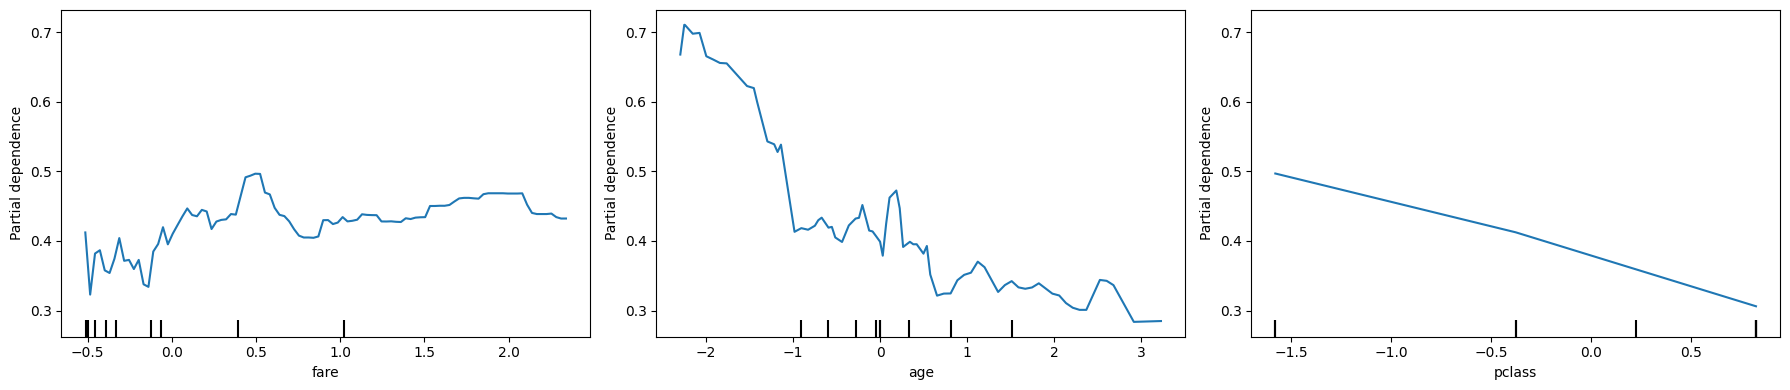

In [20]:
#### START CODE HERE -- PDP Random Forest ####
from sklearn.inspection import PartialDependenceDisplay

features = ['fare', 'age', 'pclass']
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
PartialDependenceDisplay.from_estimator(rf2, X_test, features, feature_names=feature_cols, ax=ax)
plt.tight_layout()
plt.show()
#### END CODE HERE ####

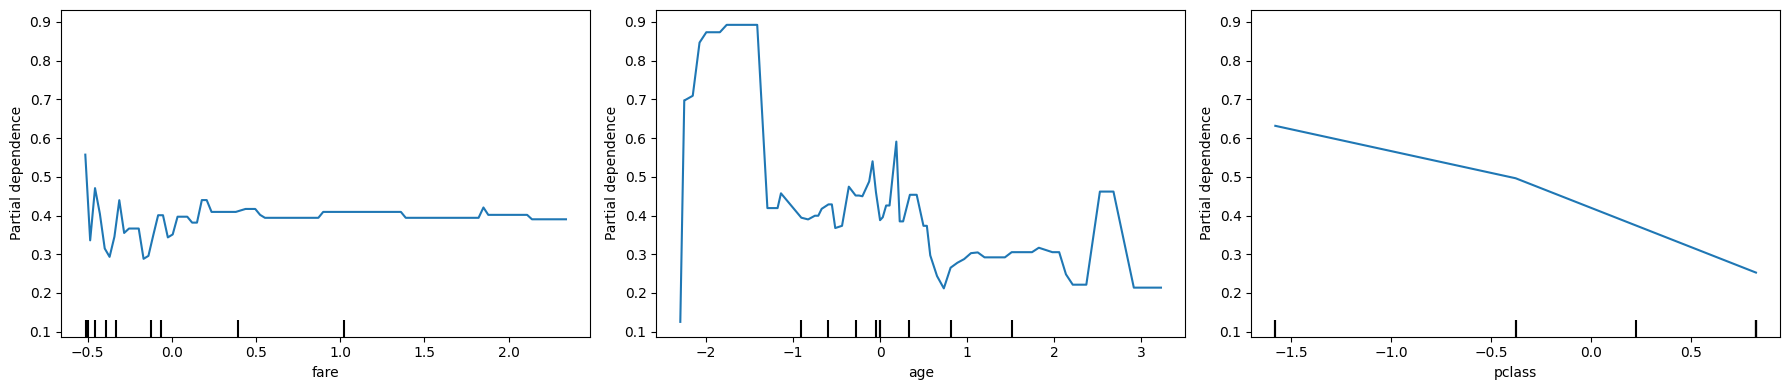

In [21]:
#### START CODE HERE -- PDP Decision Tree ####
fig, ax = plt.subplots(1, 3, figsize=(18, 4))
PartialDependenceDisplay.from_estimator(dt, X_test, features, feature_names=feature_cols, ax=ax)
plt.tight_layout()
plt.show()
#### END CODE HERE ####

## Exercise 3 — Global Surrogate Models 🪞

A **global surrogate model** is an *interpretable* model trained to **approximate** the predictions of a black-box model as accurately as possible.

> The key idea: you don't need to peek inside the black box — only its **prediction function** and a dataset are required.

**How to build a surrogate:**
1. Select a dataset X.
2. Get the **black-box predictions** for X.
3. Choose an **interpretable model type** (linear model, decision tree, …).
4. Train the interpretable model on X using the black-box predictions as labels.
5. Measure how well the surrogate **replicates** the black-box predictions (reconstruction error).

The surrogate is **model-agnostic** — it makes no assumptions about the inner workings of the black-box model.

---

### Your tasks
1. Instantiate and fit a **black-box model**: [`GradientBoostingClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.GradientBoostingClassifier.html) on the Titanic dataset.

2. Instantiate and fit a **white-box surrogate**: [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) trained on X and the *black-box predictions*.

3. **Evaluate** both models:
> * Calculate `accuracy_score` for both on train and test.
> * Calculate the **reconstruction error** — the loss of fidelity when using black-box predictions to supervise the white-box model.

4. **Inspect the surrogate's coefficients.**

> ***Hint:*** The reconstruction error measures how faithfully the white-box model mimics the black-box — lower error means a more faithful surrogate.


### 3.1 — Train the Black-Box Model

In [22]:
#### START CODE HERE ####
from sklearn.impute import SimpleImputer
from sklearn.pipeline import make_pipeline
from sklearn.ensemble import GradientBoostingClassifier

gb = make_pipeline(SimpleImputer(strategy='median'), GradientBoostingClassifier(random_state=42))
gb.fit(X_train, y_train)
print(f"GB Train accuracy: {gb.score(X_train, y_train):.4f}")
print(f"GB Test accuracy:  {gb.score(X_test, y_test):.4f}")
#### END CODE HERE ####


GB Train accuracy: 0.8606
GB Test accuracy:  0.8130


In [ ]:
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score

class TabularTransformerBlackBox(nn.Module):
    def __init__(self, input_dim, d_model=64, nhead=8, num_layers=2, dim_feedforward=128, dropout=0.1):
        super().__init__()
        self.input_dim = input_dim
        self.d_model = d_model

        # 1) Proietta ciascuna feature in d_model (token embedding)
        self.token_emb = nn.Linear(input_dim, d_model)  # oppure nn.Linear(1, d_model) + reshape per feature

        # 2) Positional embedding (optional, ma utile per sequenze feature-ordered)
        self.pos_emb = nn.Parameter(torch.zeros(1, input_dim, d_model))
        nn.init.trunc_normal_(self.pos_emb, std=0.02)

        # 3) Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            activation='relu',
            batch_first=True  # PyTorch 2.x
        )
        self.encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)

        # 4) Classificazione su stato aggregato
        self.classifier = nn.Sequential(
            nn.Linear(d_model, d_model//2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model//2, 1),
            nn.Sigmoid()
        )

        self.optimizer = torch.optim.AdamW(self.parameters(), lr=1e-3)
        self.criterion = nn.BCELoss()

    def forward(self, X):
        # X: (batch, input_dim)
        batch_size = X.shape[0]

        # token embedding (una rappresentazione di tutte le feature in un vettore "token")
        x = self.token_emb(X)                  # (batch, d_model)
        x = x.unsqueeze(1)                    # (batch, 1, d_model)
        x = x + self.pos_emb[:, :1, :]        # pos embedding su 1 token

        x = self.encoder(x)                   # (batch, 1, d_model)
        x = x.mean(dim=1)                     # (batch, d_model)
        y = self.classifier(x)                # (batch, 1)
        return y

    def fit(self, X, y, epochs=100):
        self.train()
        # Usa .values per convertire da Pandas a NumPy
        X_tensor = torch.FloatTensor(X.values if hasattr(X, 'values') else X)
        y_tensor = torch.FloatTensor(y.values if hasattr(y, 'values') else y).view(-1, 1)

        for epoch in range(epochs):
            self.optimizer.zero_grad()
            out = self.forward(X_tensor)
            loss = self.criterion(out, y_tensor)
            loss.backward()
            self.optimizer.step()
        return self

    def predict(self, X):
        self.eval()
        with torch.no_grad():
            X_tensor = torch.FloatTensor(X)
            out = self.forward(X_tensor)
            return (out.cpu().numpy() > 0.5).astype(int).flatten()

    def score(self, X, y):
        preds = self.predict(X)
        return accuracy_score(y, preds)

ttbb = TabularTransformerBlackBox(input_dim=X_train.shape[1], d_model=64, nhead=8, num_layers=2, dim_feedforward=128, dropout=0.1)
ttbb.fit(X_train, y_train, epochs=100)
print(f"TTBB Train acc: {ttbb.score(X_train, y_train):.4f}")
print(f"TTBB Test acc:  {ttbb.score(X_test, y_test):.4f}")

/tmp/ipykernel_820948/3241364864.py:62: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  y_tensor = torch.FloatTensor(y.values if hasattr(y, 'values') else y).view(-1, 1)


TTBB Train acc: 0.8290
TTBB Test acc:  0.8359


### 3.2 — Train the White-Box Surrogate

In [24]:
#### START CODE HERE ####
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

bb_preds_train = ttbb.predict(X_train)
surrogate = make_pipeline(
    SimpleImputer(strategy='median'),
    LogisticRegression(max_iter=1000, random_state=42)
)
surrogate.fit(X_train, bb_preds_train)
#### END CODE HERE ####


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('simpleimputer', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite 

### 3.3 — Inspect Surrogate Coefficients

In [25]:
#### START CODE HERE ####
coef_series = pd.Series(surrogate.named_steps['logisticregression'].coef_[0], index=feature_cols)
print("Surrogate coefficients sorted by absolute value:")
print(coef_series.abs().sort_values(ascending=False))
print("\nOriginal coefficients:")
print(coef_series.sort_values(ascending=False))
#### END CODE HERE ####


Surrogate coefficients sorted by absolute value:
sex           2.466634
pclass        2.088511
embarked_S    1.468332
age           1.047691
embarked_Q    1.032254
embarked_C    0.439052
sibsp         0.420542
parch         0.240038
fare          0.180587
dtype: float64

Original coefficients:
embarked_Q    1.032254
embarked_C    0.439052
parch         0.240038
fare         -0.180587
sibsp        -0.420542
age          -1.047691
embarked_S   -1.468332
pclass       -2.088511
sex          -2.466634
dtype: float64


### 3.4 — Evaluate Both Models

In [26]:
#### START CODE HERE ####
from sklearn.metrics import accuracy_score

y_bb_test = ttbb.predict(X_test)

print("Black-box accuracy:")
print("Train:", accuracy_score(y_train, gb.predict(X_train)))
print("Test: ", accuracy_score(y_test, y_bb_test))

print("\nSurrogate accuracy vs black-box labels:")
print("Train:", accuracy_score(bb_preds_train, surrogate.predict(X_train)))
print("Test: ", accuracy_score(y_bb_test, surrogate.predict(X_test)))
#### END CODE HERE ####

Black-box accuracy:
Train: 0.8605539637058262
Test:  0.8358778625954199

Surrogate accuracy vs black-box labels:
Train: 0.9197707736389685
Test:  0.9236641221374046


### 3.5 — Reconstruction Error

In [27]:
#### START CODE HERE ####
recon_err_train = 1.0 - accuracy_score(bb_preds_train, surrogate.predict(X_train))
recon_err_test = 1.0 - accuracy_score(y_bb_test, surrogate.predict(X_test))
print(f"Reconstruction error (train): {recon_err_train:.4f}")
print(f"Reconstruction error (test):  {recon_err_test:.4f}")
#### END CODE HERE ####


Reconstruction error (train): 0.0802
Reconstruction error (test):  0.0763


### 🔍 Reflection Questions

1. **Permutation Feature Importance:** Why does permutation importance on the *training set* give a different result than on the *test set* for the unconstrained Random Forest? What does `min_samples_leaf=20` change, and why?

2. **PDP:** The PDP shows the *average* marginal effect. If `fare` and `pclass` are correlated, what risk do you run when interpreting each PDP independently? How could you detect this problem?

3. **Surrogate Model:** A high reconstruction error means the white-box model cannot replicate the black-box well. In that case, is the surrogate still a valid explanation of the black-box? What would you do?

4. **General:** All three methods are **post-hoc** and **global**. Can a global explanation mislead you in a specific individual prediction? Give an example using the Titanic context (e.g. first-class women vs third-class men).
